---
title: "Case Study Comparison"
date: 2025-04-12
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

There are several hyperparameters we can vary in the clustering algorithm, including `epsilon_space`, `epsilon_time`, `min_pts`, and `rep_pts`. For our final catalog, our choices of hyperparameters were motivated by the meteorology of ARs in Antarctica as well as community standards for defining ARs. Our choices of these parameters were the following:

+ `epsilon_space`: 0.5
+ `epsilon_time`: 12
+ `min_pts`: 5
+ `rep_pts`: 10

This effort is to address issues with the clustering algorithm where, for certain combinations of hyperparameters, the same storm system may be given different labels if it disappeared for long enough from the original catalog, or that separate systems may be given the same label if they occur near to one another in space and time. In this notebook, we compare our clustering output to specific AR case studies identified in the literature, verifying our catalog with the above set of hyperparameters captures the event in its full duration with landfalling location consistent with that externally reported.

In [1]:
# import packages/functions
import pandas as pd
from artools.format_utils import to_stormtime_format
from artools.display_utils import make_movie, make_eulerian_movie, display_catalog, plot_stormtime_grid
from artools.loading_utils import load_catalog, load_wille_catalogs
from datetime import date

from IPython.display import Video

We first load up the catalog in `pandas.DataFrame` format, where each row corresponds to a particular AR. We extract all of the landfalling ARs only, and then convert the catalog to storm-time format. Storm-time format refers to a `pandas.DataFrame` object where each row corresponds to a storm at a particular point in time of that storm's lifetime, and columns include lists of the coordinates that comprise that storm's footprint at that time. This format is much more amenable for plotting and making movies of multiple ARs at a particular time.

In [2]:
catalog = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
landfalling = catalog[catalog.is_landfalling]

stormtime_format = to_stormtime_format(landfalling, show_progress=True)

Processing storms:   0%|          | 0/3179 [00:00<?, ?it/s]

For the case studies of interest, we will susbet this DataFrame to include only those rows whose time corresponds roughly to the AR impact dates provided in the associated papers.

### AR 1

+ **Date(s):** March 23-24, 2015
+ **Location:** Antarctic Peninsula
+ **Reference paper:** *[Foehn Event Triggered by an Atmospheric River Underlies Record-Setting Temperature Along Continental Antarctica](https://doi.org/10.1002/2017JD027796)*

In [12]:
ani_name = 'bozkurt2018.mp4'

start = date(2015, 3, 21)
end = date(2015, 3, 26)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Bozkurt et al. (2018)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/bozkurt2018.mp4...


  0%|          | 0/25 [00:00<?, ?it/s]

### AR 2

+ **Date(s):** January 8-10, 2019
+ **Location:** East Antarctica (Vestfold Hills)
+ **Reference paper:** *[Orographic Flow Influence on Precipitation During an Atmospheric River Event at Davis, Antarctica](https://doi.org/10.1029/2021JD035210)*

In [13]:
ani_name = 'gehring2022.mp4'

start = date(2019, 1, 6)
end = date(2019, 1, 13)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gehring et al. (2022)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gehring2022.mp4...


  0%|          | 0/29 [00:00<?, ?it/s]

### AR 3

+ **Date(s):** February 7-9, 2022
+ **Location:** Antarctic Peninsula
+ **Reference paper:** *[Record-high Antarctic Peninsula temperatures and surface
melt in February 2022: a compound event with an intense
atmospheric river](https://doi.org/10.1038/s41612-023-00529-6)*

In [14]:
ani_name = 'gorodetskaya2023.mp4'

start = date(2022, 2, 5)
end = date(2022, 2, 11)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2023)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2023.mp4...


  0%|          | 0/34 [00:00<?, ?it/s]

### AR 4

+ **Date(s):** November 16-17, 2018
+ **Location:** East Antarctica (Dronning Maud Land)
+ **Reference paper:** *[Atmospheric River Signatures in Radiosonde Profiles and Reanalyses at the Dronning Maud Land Coast, East Antarctica](https://doi.org/10.1007/s00376-020-9221-8)*

In [15]:
ani_name = 'gorodetskaya2020_1.mp4'

start = date(2018, 11, 14)
end = date(2018, 11, 19)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2020)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2020_1.mp4...


  0%|          | 0/26 [00:00<?, ?it/s]

### AR 5

+ **Date(s):** December 18, 2018
+ **Location:** East Antarctica (Dronning Maud Land)
+ **Reference paper:** *[Atmospheric River Signatures in Radiosonde Profiles and Reanalyses at the Dronning Maud Land Coast, East Antarctica](https://doi.org/10.1007/s00376-020-9221-8)*

In [16]:
ani_name = 'gorodetskaya2020_2.mp4'

start = date(2018, 12, 16)
end = date(2018, 12, 20)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2020)', '../../output/animations/' + ani_name)\

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2020_2.mp4...


  0%|          | 0/17 [00:00<?, ?it/s]

### AR 6-8

+ **Date(s):** February 2, 2020 (6h landfall); February 3-5, 2020; February 7-8, 2020
+ **Location:** West Antarctica (Thwaites Glacier; Marie Byrd Land)
+ **Reference paper:** *[Climatology and surface impacts of atmospheric rivers on West Antarctica](https://doi.org/10.5194/tc-17-865-2023)*

In [16]:
ani_name = 'maclennan2023.mp4'

start = date(2020, 1, 31)
end = date(2020, 2, 10)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Maclennan et al. (2023)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/maclennan2023.mp4...


  0%|          | 0/76 [00:00<?, ?it/s]

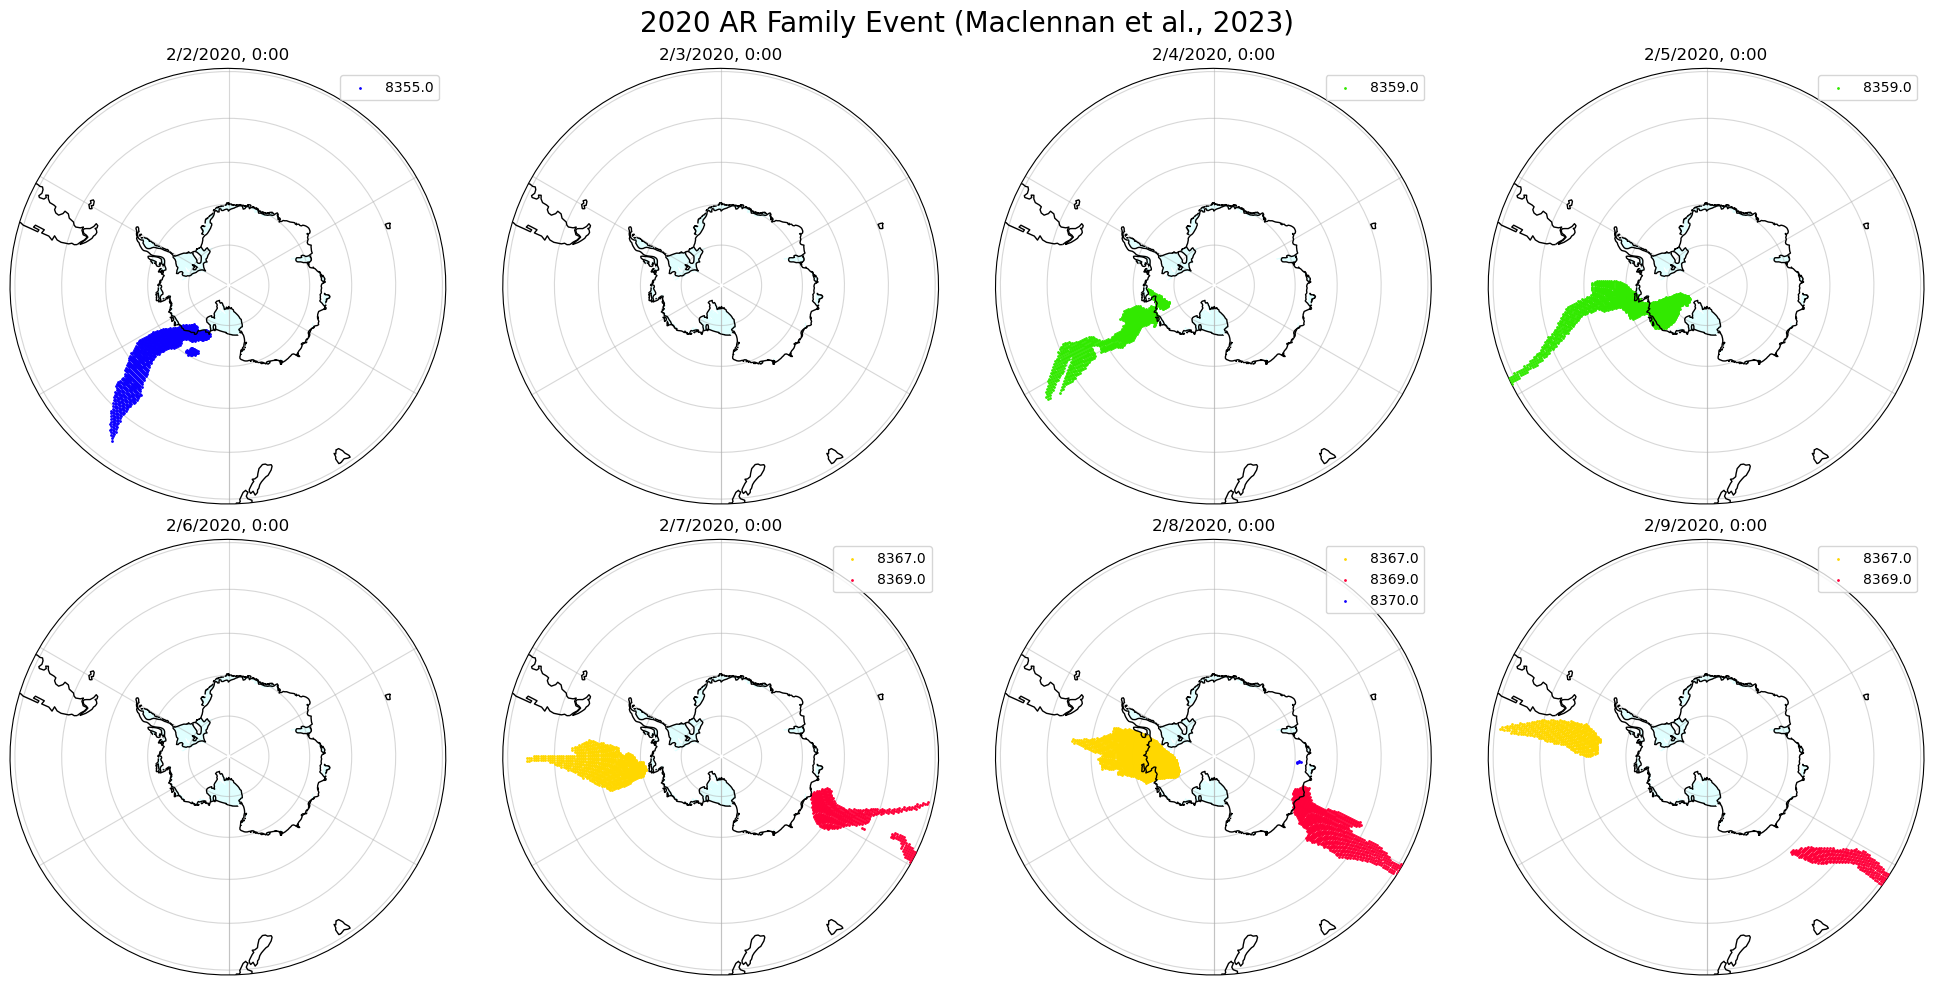

In [20]:
start = date(2020, 2, 2)
end = date(2020, 2, 9)
freq = '1d'
ncols = 4
fig, axes = plot_stormtime_grid(start, end, stormtime_subset, freq, ncols)
fig.suptitle('2020 AR Family Event (Maclennan et al., 2023)', fontsize=20)
fig.tight_layout()
fig.savefig('../../output/plots/maclennan_event_frames.png', dpi=300)

### AR 9

+ **Date(s):** March 14-18, 2024
+ **Location:** East Antarctica (west of Dumont D’Urville station)
+ **Reference paper:** *[The Extraordinary March 2022 East Antarctica “Heat” Wave. Part II: Impacts on the Antarctic Ice Sheet](https://doi.org/10.1175/JCLI-D-23-0176.1)*

In [18]:
ani_name = 'wille2024.mp4'

start = date(2022, 3, 12)
end = date(2022, 3, 20)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Wille et al. (2024)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/wille2024.mp4...


  0%|          | 0/58 [00:00<?, ?it/s]

### AR 10

+ **Date(s):** January 24-26, 2008
+ **Location:** Antarctic Peninsula
+ **Reference paper:** *[Intense atmospheric rivers can weaken ice shelf stability at the Antarctic Peninsula](https://doi.org/10.1038/s43247-022-00422-9)*

In [19]:
ani_name = 'wille2022_1.mp4'

start = date(2008, 1, 22)
end = date(2008, 1, 28)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Wille et al. (2022)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')


Saving animation to ../../output/animations/wille2022_1.mp4...


  0%|          | 0/18 [00:00<?, ?it/s]

### AR 11

+ **Date(s):** January 24-25, 1995
+ **Location:** Antarctic Peninsula
+ **Reference paper:** *[Intense atmospheric rivers can weaken ice shelf stability at the Antarctic Peninsula](https://doi.org/10.1038/s43247-022-00422-9)*

In [20]:
ani_name = 'wille2022_2.mp4'

start = date(1995, 1, 22)
end = date(1995, 1, 28)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Wille et al. (2022)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/wille2022_2.mp4...


  0%|          | 0/16 [00:00<?, ?it/s]

### AR 12-14

+ **Date(s):** February 4-5, 2002; February 18-20, 2002; February 25-27, 2002
+ **Location:** Antarctic Peninsula
+ **Reference paper:** *[Intense atmospheric rivers can weaken ice shelf stability at the Antarctic Peninsula](https://doi.org/10.1038/s43247-022-00422-9)*

In [21]:
ani_name = 'wille2022_3.mp4'

start = date(2002, 1, 25)
end = date(2002, 2, 28)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Wille et al. (2022)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/wille2022_3.mp4...


  0%|          | 0/201 [00:00<?, ?it/s]

It seems we are missing the February 4-5 and February 18-20 events. Let's take a look at the original Wille et al. catalog to see if these events were present in the first place.

In [22]:
wille_catalog = load_wille_catalogs(dir_path='../../input_data/wille_ar_catalogs', years=[2002], exclude_empty_times=False)
feb_wille_catalog = wille_catalog.sel(time=wille_catalog.time.dt.month == 2).compute()

In [23]:
ani_name = 'wille2022_missing_eulerian.mp4'
ani = make_eulerian_movie(feb_wille_catalog, 'Missing 2002 Events', '../../output/animations/' + ani_name)
Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/wille2022_missing_eulerian.mp4...


  0%|          | 0/224 [00:00<?, ?it/s]

In the first 10 seconds of this animation, we can see the February 4-5 AR zeroing in on the Antarctic Peninsula before abruptly diseappearing before landfall. As our catalog only looks at events which make landfall, this AR is not included. Similarly, on February 17 (around 25 seconds), we can see what appears to be the February 18-20 event moving towards the AP before also disappearing, never making landfall.

### AR 15-16

+ **Date(s):** May 18-19, 2009; May 25, 2009
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [24]:
ani_name = 'gorodetskaya2014_1.mp4'

start = date(2009, 5, 16)
end = date(2009, 5, 27)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_1.mp4...


  0%|          | 0/80 [00:00<?, ?it/s]

### AR 17

+ **Date(s):** June 15-16, 2009
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [25]:
ani_name = 'gorodetskaya2014_2.mp4'

start = date(2009, 6, 13)
end = date(2009, 6, 18)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_2.mp4...


  0%|          | 0/48 [00:00<?, ?it/s]

### AR 18

+ **Date(s):** July 5-6, 2009
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [26]:
ani_name = 'gorodetskaya2014_3.mp4'

start = date(2009, 7, 3)
end = date(2009, 7, 8)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_3.mp4...


  0%|          | 0/48 [00:00<?, ?it/s]

### AR 19

+ **Date(s):** February 14-16, 2011
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [27]:
ani_name = 'gorodetskaya2014_4.mp4'

start = date(2011, 2, 12)
end = date(2011, 2, 18)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_4.mp4...


  0%|          | 0/40 [00:00<?, ?it/s]

### AR 20

+ **Date(s):** June 24, 2011
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [22]:
ani_name = 'gorodetskaya2014_5.mp4'

start = date(2011, 6, 22)
end = date(2011, 6, 28)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_5.mp4...


  0%|          | 0/56 [00:00<?, ?it/s]

There is a smaller blob of AR pixels that appears to come from Argentina, catching up with the main event as it makes landfall. While it remains a distinct blob, it does get fairly close to the AR, so it is questionable if these events should be considered to have joined together.

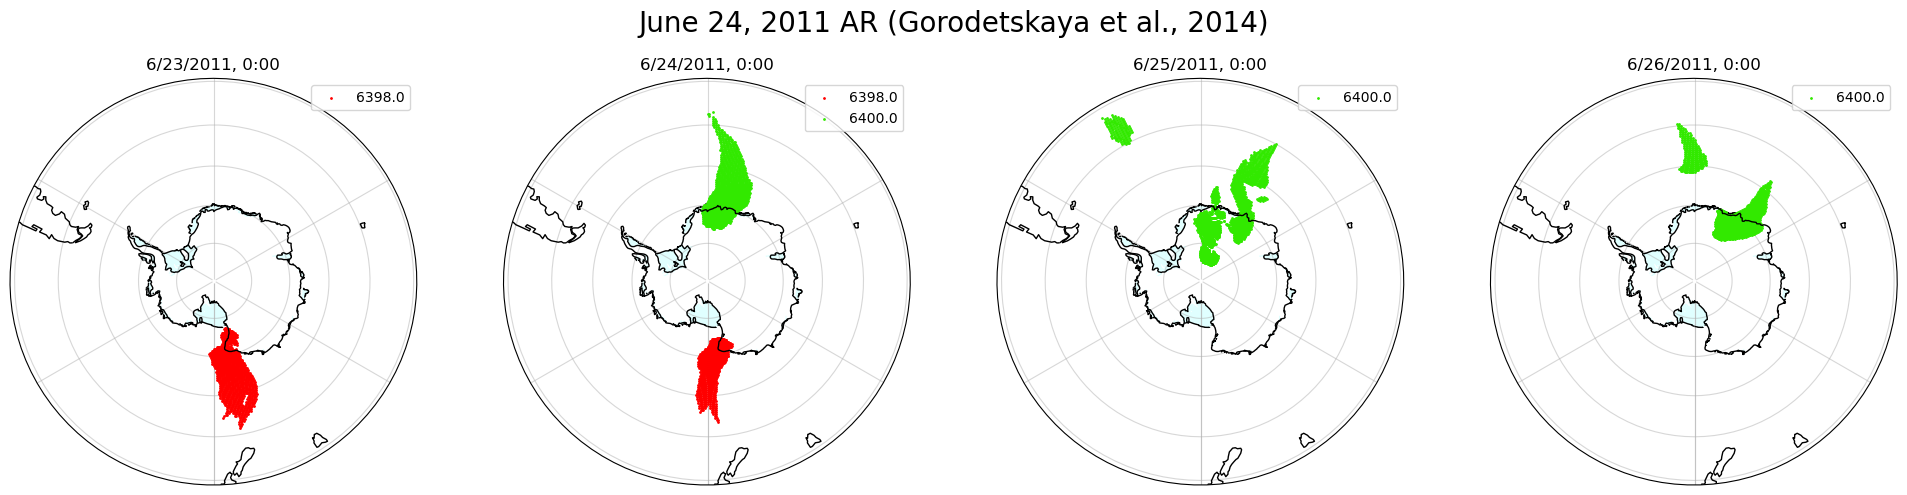

In [24]:
start = date(2011, 6, 23)
end = date(2011, 6, 26)
freq = '1d'
ncols = 4
fig, axes = plot_stormtime_grid(start, end, stormtime_subset, freq, ncols)
fig.suptitle('June 24, 2011 AR (Gorodetskaya et al., 2014)', fontsize=20)
fig.tight_layout()
fig.savefig('../../output/plots/gorodetskaya_event_frames.png', dpi=300)

### AR 21

+ **Date(s):** November 20-21, 2011
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [29]:
ani_name = 'gorodetskaya2014_6.mp4'

start = date(2011, 11, 18)
end = date(2011, 11, 23)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_6.mp4...


  0%|          | 0/41 [00:00<?, ?it/s]

### AR 22-23

+ **Date(s):** December 15-17, 2011; December 19-20, 2011
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [30]:
ani_name = 'gorodetskaya2014_7.mp4'

start = date(2011, 12, 13)
end = date(2011, 12, 22)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_7.mp4...


  0%|          | 0/66 [00:00<?, ?it/s]

The December 15-17 AR is clearly present, but the December 19-20 AR does not appear. As before, let's check the original Wille et al. catalogs to see if this AR also existed over the Southern Ocean, but just wasn't included in our landfalling catalog since the AR never made landfall.

In [31]:
wille_catalog = load_wille_catalogs(dir_path='../../input_data/wille_ar_catalogs', years=[2011], exclude_empty_times=False)
dec_wille_catalog = wille_catalog.sel(time=wille_catalog.time.dt.month == 12).compute()

In [32]:
ani_name = 'gorodetskaya2014_missing_eulerian.mp4'
ani = make_eulerian_movie(dec_wille_catalog, 'Missing 2011 Event', '../../output/animations/' + ani_name)
Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_missing_eulerian.mp4...


  0%|          | 0/248 [00:00<?, ?it/s]

On December 18 at 09:00 (around 27 seconds), it appears there's a flicker of an AR over the Southern Ocean after the previous AR completed its landfall. However, it quickly disappears from the original catalog and does not seem to reappear, explaining its absence from our catalog.

### AR 24

+ **Date(s):** November 6, 2012
+ **Location:**  East Antarctica (Princess Elizabeth station near Dronning Maud Land)
+ **Reference paper:** *[The role of atmospheric rivers in anomalous snow
accumulation in East Antarctica](https://doi.org/10.1002/2014GL060881)*

In [33]:
ani_name = 'gorodetskaya2014_8.mp4'

start = date(2012, 11, 4)
end = date(2012, 11, 8)

stormtime_subset = stormtime_format[stormtime_format['time'].dt.date.between(start, end, inclusive='both')]
ani = make_movie(stormtime_subset, 'Gorodetskaya et al. (2014)', '../../output/animations/' + ani_name)

Video('../../output/animations/' + ani_name, embed=True, html_attributes='controls')

Saving animation to ../../output/animations/gorodetskaya2014_8.mp4...


  0%|          | 0/21 [00:00<?, ?it/s]